<a href="https://colab.research.google.com/github/D-LukeSherman/ECGR-4105/blob/main/Homework4/Homework4_Problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.svm import SVC
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler


In [2]:
# Use the URL for the raw CSV data
url = 'https://raw.githubusercontent.com/D-LukeSherman/ECGR-4105/refs/heads/main/Homework4/Cancer.csv'

dataset = pd.read_csv(url)

# Preprocessing

varlist = ['diagnosis']

def binary_map(x):
    return x.map({'M': 1, 'B': 0})

dataset[varlist] = dataset[varlist].apply(binary_map)

# Separating out the features
x = dataset.iloc[:, 2:].values
# Separating out the target
y = dataset.iloc[:, 1].values

Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2,
                                                random_state=0)

sc_X = StandardScaler()
Xtrain = sc_X.fit_transform(Xtrain)
Xtest = sc_X.transform(Xtest)

In [3]:
# display(dataset)

In [4]:
model_rbf = SVC(kernel = 'rbf', class_weight = 'balanced')
param_grid = {'C': [1, 5, 10, 50],
              'gamma': [0.001, 0.005, 0.01, 0.05]}
grid = GridSearchCV(model_rbf, param_grid) #GridSearchCV determines the best model

grid.fit(Xtrain, ytrain)
print(grid.best_params_)

{'C': 10, 'gamma': 0.005}


In [5]:
#The optimal values fall toward the middle of our grid;
#if they fell at the edges, we would want to expand the grid to make sure we have found the true optimum.
#Now with this cross-validated model, we can predict the labels for the test data
model_rbf = grid.best_estimator_
yfit = model_rbf.predict(Xtest)

print(classification_report(ytest, yfit,
                            target_names=['malignant', 'benign']))


              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        67
      benign       0.96      0.98      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



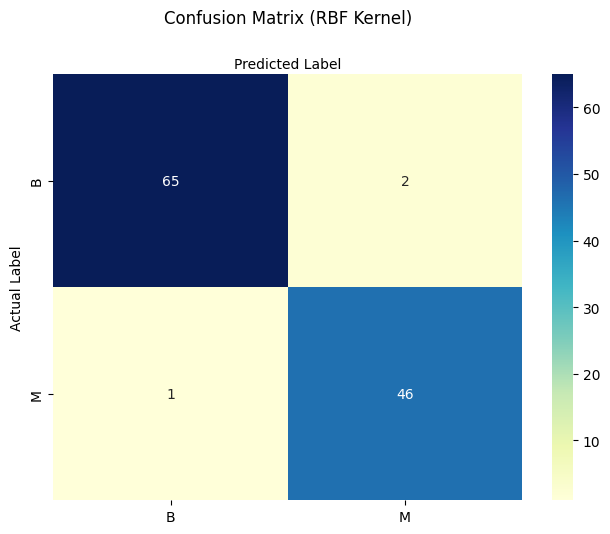

In [6]:
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(ytest, yfit)

import seaborn as sns

class_names = ['B', 'M']  # 0 = Benign, 1 = Malignant

fig, ax = plt.subplots()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Create heatmap
sns.heatmap(
    pd.DataFrame(cnf_matrix),
    annot=True,
    cmap="YlGnBu",
    fmt='g',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.xaxis.set_label_position("top")

plt.tight_layout()
plt.title('Confusion Matrix (RBF Kernel)', y=1.1)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [7]:
model_linear = SVC(kernel = 'linear')
grid = GridSearchCV(model_linear, param_grid) #GridSearchCV determines the best model

grid.fit(Xtrain, ytrain)
print(grid.best_params_)

{'C': 1, 'gamma': 0.001}


In [8]:
model_linear = grid.best_estimator_
yfit = model_linear.predict(Xtest)

print(classification_report(ytest, yfit,
                            target_names=['malignant', 'benign']))

              precision    recall  f1-score   support

   malignant       0.99      0.99      0.99        67
      benign       0.98      0.98      0.98        47

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



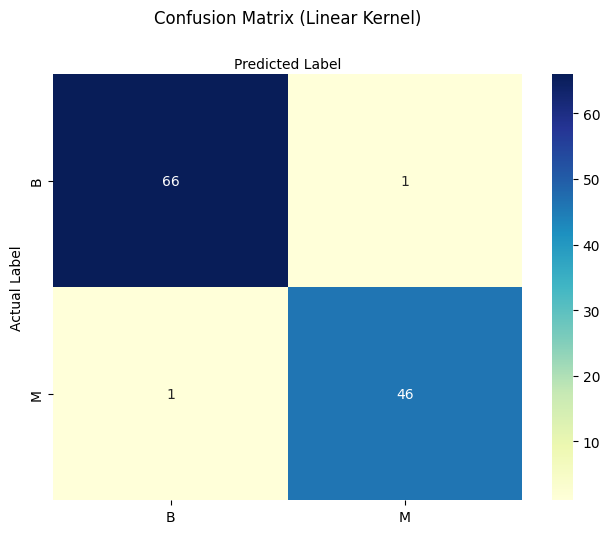

In [9]:
# Recalculate confusion matrix for the Linear model
cnf_matrix_linear = confusion_matrix(ytest, yfit)

fig, ax = plt.subplots()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Create heatmap for Linear SVM
sns.heatmap(
    pd.DataFrame(cnf_matrix_linear),
    annot=True,
    cmap="YlGnBu",
    fmt='g',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.xaxis.set_label_position("top")

plt.tight_layout()
plt.title('Confusion Matrix (Linear Kernel)', y=1.1)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [10]:
model_poly = SVC(kernel='poly', degree=2)
grid = GridSearchCV(model_poly, param_grid) #GridSearchCV determines the best model

grid.fit(Xtrain, ytrain)
print(grid.best_params_)

{'C': 10, 'gamma': 0.05}


In [11]:
model_poly = grid.best_estimator_
yfit = model_poly.predict(Xtest)

print(classification_report(ytest, yfit,
                            target_names=['malignant', 'benign']))

              precision    recall  f1-score   support

   malignant       0.79      0.94      0.86        67
      benign       0.88      0.64      0.74        47

    accuracy                           0.82       114
   macro avg       0.83      0.79      0.80       114
weighted avg       0.83      0.82      0.81       114



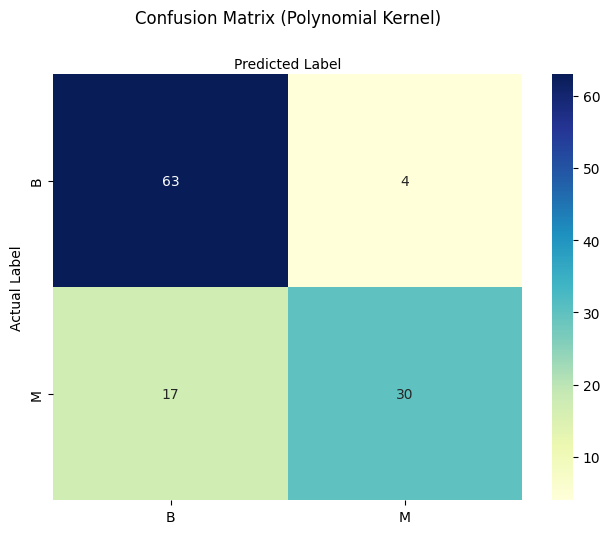

In [12]:
# Recalculate confusion matrix for the Polynomial model
cnf_matrix_poly = confusion_matrix(ytest, yfit)

fig, ax = plt.subplots()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Create heatmap for Polynomial SVM
sns.heatmap(
    pd.DataFrame(cnf_matrix_poly),
    annot=True,
    cmap="YlGnBu",
    fmt='g',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.xaxis.set_label_position("top")

plt.tight_layout()
plt.title('Confusion Matrix (Polynomial Kernel)', y=1.1)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

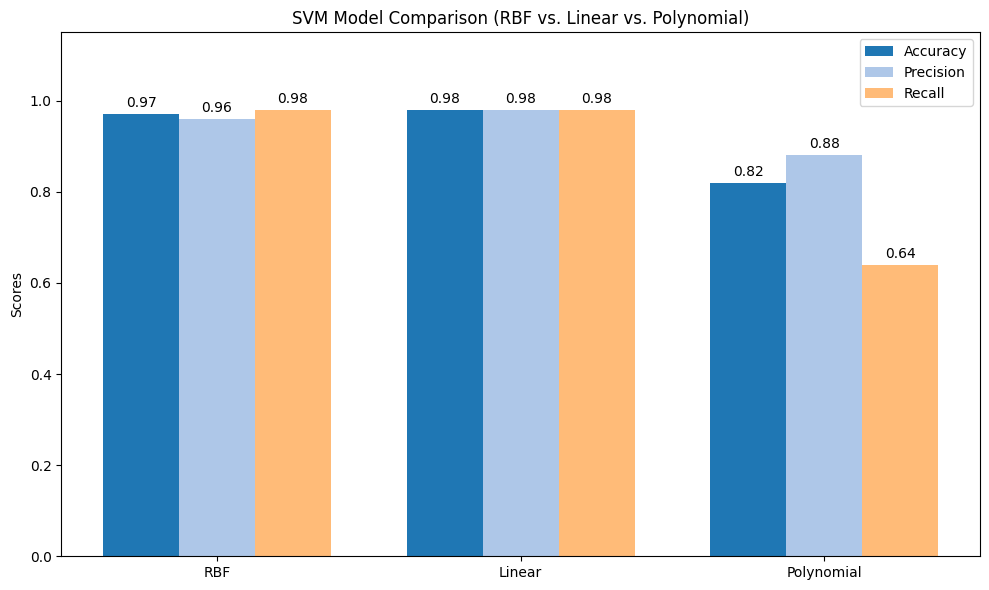

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data to plot
models = ['RBF', 'Linear', 'Polynomial']
metrics = ['Accuracy', 'Precision', 'Recall']

# Extract scores from classification reports
# RBF: Acc=0.97, Prec=0.96 (benign), Rec=0.98 (benign)
# Linear: Acc=0.98, Prec=0.98 (benign), Rec=0.98 (benign)
# Poly: Acc=0.82, Prec=0.88 (benign), Rec=0.64 (benign)
scores = {
    'Accuracy': [0.97, 0.98, 0.82],
    'Precision': [0.96, 0.98, 0.88],
    'Recall': [0.98, 0.98, 0.64]
}

x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each metric
rects1 = ax.bar(x - width, scores['Accuracy'], width, label='Accuracy', color='#1f77b4')
rects2 = ax.bar(x, scores['Precision'], width, label='Precision', color='#aec7e8')
rects3 = ax.bar(x + width, scores['Recall'], width, label='Recall', color='#ffbb78')

# Add details
ax.set_ylabel('Scores')
ax.set_title('SVM Model Comparison (RBF vs. Linear vs. Polynomial)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.15)
ax.legend()

# Attach text labels above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()